# Updated Notebook by Jack Mulvihill

## Research Question
**Given** the OpenAlex tables “Works” and “Works Authorships” provide information about
citation counts, authors, and the institution that published these works between 2020 and 2025.

**Then** we aim to identify which institutions and combinations of institutions are most frequently
associated with highly cited research during this period.

**How** we will approach this is by each highly cited paper we will look at the institutions
represented by its authors and analyze which institutions frequently appear together in impactful
research. Using frequent pattern mining we will identify recurring patterns and determine which
combinations are most associated with highly cited works.


## Institutions Publishing Highly Cited Works and their Co-Authorship Patterns

## Imported Libraries

In [2]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow.parquet as pypq
import textwrap 

# For sampling
import random

# For Apriori (Frequent Pattern Mining)
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# For counting and filtering frequent item pairs
from collections import Counter

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)

# ---------------------------------------------------------
# 📂 GLOBAL PATHS - DO NOT CHANGE THESE
# ---------------------------------------------------------
BASE_PATH = Path("/data/shared/OpenAlex/processed-snapshots")
PARQUET_PATH = BASE_PATH / "parquet-files" / "may-2025"
CSV_PATH = BASE_PATH / "csv-files" / "may-2025"

print(f"✅ Data Directories Set:\n  - Parquet: {PARQUET_PATH}\n  - CSV: {CSV_PATH}")

# Focusing on works published within the most recent complete five year range, 2019-2024
MIN_YEAR = 2019
MAX_YEAR = 2024 # 2025 does not have complete data on all works published that year

# Consider a work with 50 or more citations "highly cited"
MIN_CITS = 50

✅ Data Directories Set:
  - Parquet: /data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025
  - CSV: /data/shared/OpenAlex/processed-snapshots/csv-files/may-2025


## Peek Parquet (Inspects File Schemas)

In [2]:
def peek_parquet(path):
    """
    peeks at a parquet file (or a directory containing parquet files) without reading the whole thing and prints the following:
    * Path
    * schema
    * number of pieces (fragments)
    * number of rows 
    """
    path = Path(path)
    parq_file = pypq.ParquetDataset(path)
    piece_count = len(parq_file.fragments)
    schema = textwrap.indent(parq_file.schema.to_string(), ' '*4)
    row_count = sum(frag.count_rows() for frag in parq_file.fragments)
    
    st = [
        f'Name: {path.stem!r}',  
        f'Path: {str(path)!r}',
        f'Files: {piece_count:,}',
        f'Rows: {row_count:,}',
        f'Schema:\n{schema}',
        f'5 random rows:',
    ]
    print('\n'.join(st))
    sample_df = parq_file.fragments[0].head(5).to_pandas()  # read 5 rows from the first fragment
    display(sample_df)

    return

## Primary Tables: Works and Works Authorships

In [3]:
peek_parquet(PARQUET_PATH / 'works')

Name: 'works'
Path: '/data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025/works'
Files: 879
Rows: 267,515,390
Schema:
    work_id: int64
    doi: string
    title: string
    publication_year: int16
    publication_date: timestamp[ms]
    type: dictionary<values=string, indices=int32, ordered=0>
    type_crossref: dictionary<values=string, indices=int32, ordered=0>
    cited_by_count: uint32
    num_authors: uint16
    num_locations: uint16
    num_references: uint16
    language: dictionary<values=string, indices=int32, ordered=0>
    has_complete_institution_info: bool
    has_grant_info: bool
    has_keywords: bool
    is_retracted: bool
    is_paratext: bool
    created_date: timestamp[ms]
    gz_path: dictionary<values=string, indices=int32, ordered=0>
    -- schema metadata --
    pandas: '{"index_columns": [], "column_indexes": [{"name": null, "field_n' + 2664
5 random rows:


,work_id,doi,title,publication_year,publication_date,type,type_crossref,cited_by_count,num_authors,num_locations,num_references,language,has_complete_institution_info,has_grant_info,has_keywords,is_retracted,is_paratext,created_date,gz_path
0,4298954679,<NA>,Anomalous cooling of the parallel velocity in seeded beams,2004,2004-06-16,article,posted-content,0,4,6,0,en,False,False,False,False,False,2022-10-02,2023-05-29_part_000
1,4367174134,10.41014/jmb.2301.01011,Comparative Genomic Analysis and BTEX Degradation Pathways of a Thermotolera...,2023,2023-04-10,article,journal-article,0,6,1,0,en,True,False,False,False,False,2023-04-28,2023-05-29_part_000


In [4]:
# Construct a dataframe from the original parquet files
works_df = (
  pd.read_parquet(
    PARQUET_PATH / 'works',

    # Include relevant columns to this analysis
    columns=['work_id', 'cited_by_count', 
             'num_references', 'has_complete_institution_info'],

    # Only include papers published within our desired period of analysis
    # Only include papers that have received 50 or more citations
    # Make sure it has complete information about publication
    filters=[
      [
        ('publication_year', '>=', MIN_YEAR), ('publication_year', '<=', MAX_YEAR),
        ('cited_by_count', '>=', MIN_CITS), ('has_complete_institution_info', '==', True), 
      ]
    ],
  )
)

Create a DataFrame of works with their work ID and citation count including only "highly cited" (50 or more citations) works. We are only interested in "highly cited" works published within 2019-2024 and have complete information regarding their institution of origin. 

In [5]:
display(works_df.head())

,work_id,cited_by_count,num_references,has_complete_institution_info
0,4223541591,184,157,True
1,3025854696,67,107,True
2,2936380844,84,20,True
3,2047643587,86,0,True
4,4225729190,115,0,True


In [6]:
peek_parquet(PARQUET_PATH / 'works_authorships')

Name: 'works_authorships'
Path: '/data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025/works_authorships'
Files: 876
Rows: 955,891,469
Schema:
    work_id: int64
    author_position: dictionary<values=string, indices=int32, ordered=0>
    author_id: int64
    author_name: string
    raw_author_name: string
    institution_lineage_level: int8
    assigned_institution: bool
    institution_id: int64
    institution_name: dictionary<values=string, indices=int32, ordered=0>
    country_code: dictionary<values=string, indices=int32, ordered=0>
    raw_affiliation_string: string
    publication_year: int16
    is_corresponding: bool
    -- schema metadata --
    pandas: '{"index_columns": [], "column_indexes": [{"name": null, "field_n' + 1971
5 random rows:


,work_id,author_position,author_id,author_name,raw_author_name,institution_lineage_level,assigned_institution,institution_id,institution_name,country_code,raw_affiliation_string,publication_year,is_corresponding
0,4298954679,first,5058811708,Alain Miffre,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
1,4298954679,middle,5030850284,Marion Jacquey,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
2,4298954679,middle,5080689989,Gérard Trénec,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
3,4298954679,last,5025008933,J. Vigué,<NA>,0,True,<NA>,NaN,NaN,<NA>,2004,False
4,4367174134,first,5051167699,Chandran Sathesh-Prabu,<NA>,0,False,<NA>,NaN,NaN,"School of Energy and Chemical Engineering, Ulsan National Institute of Scien...",2023,False


In [7]:
# A set of the relevant work IDs (highly cited) filtered in the previous step
# Use a set to avoid storing duplicates
work_ids = set(works_df.work_id)

# Construct a dataframe from the original parquet files
works_authors_df = (
  pd.read_parquet(
    PARQUET_PATH / 'works_authorships',

    # Include relevant columns to this analysis
    columns=['work_id', 'institution_id', 
             'institution_name', 'publication_year'],
    
    # Only load authorship information for works that survived the initial filtering when creating works_df
    # Only include works published in 2019-2024
    filters=[[
      ('work_id', 'in', work_ids),
      ('publication_year', '>=', MIN_YEAR), ('publication_year', '<=', MAX_YEAR)
    ]],
  )
)

This DataFrame works_authors_df loads the authorship information for the works filtered out in creating the works_df DataFrame. Creating this DataFrame will fetch the institution information for the "highly cited" works mined along with their publication year.

In [8]:
display(works_authors_df)

,work_id,institution_id,institution_name,publication_year
0,4223541591,38706770,Guilin University of Technology,2022
1,4223541591,38706770,Guilin University of Technology,2022
2,4223541591,38706770,Guilin University of Technology,2022
3,4223541591,38706770,Guilin University of Technology,2022
4,3025854696,138690464,University of Ghana,2020
...,...,...,...,...
9136968,4403686047,204983213,Harbin Institute of Technology,2024
9136969,4403686047,204983213,Harbin Institute of Technology,2024
9136970,4403686047,204983213,Harbin Institute of Technology,2024
9136971,4403686047,204983213,Harbin Institute of Technology,2024


# Highly Cited Works and their Institution of Origin

In [9]:
# Create a temporary dataframe to merge the works and works_authors tables
temp_df = pd.merge(
    works_authors_df,
    works_df,

    # They both share work_id
    on='work_id',

    # Combines rows when there is a matching column
    how='inner'
)

# Drop duplicates from the newly merged dataframes, keep first occurrence
# Pay attention to work ID and institution ID combos for identifying duplicates
works_institutions_df = temp_df.drop_duplicates(keep='first', subset=['work_id', 'institution_id'])

Create a new DataFrame works_institutions_df which combines the desired information mined earlier into one DataFrame for easier analysis.

In [10]:
display(works_institutions_df.head())

,work_id,institution_id,institution_name,publication_year,cited_by_count,num_references,has_complete_institution_info
0,4223541591,38706770,Guilin University of Technology,2022,184,157,True
4,3025854696,138690464,University of Ghana,2020,67,107,True
5,3025854696,130828816,University of Leeds,2020,67,107,True
7,2936380844,63098007,Liverpool John Moores University,2019,84,20,True
12,2936380844,4210129695,United Utilities (United Kingdom),2019,84,20,True


In [11]:
# Save as a parquet file to quickly load filtered data in event of a kernel crash
works_institutions_df.to_parquet(path='/home/jupyter-jmulvihill@luc.edu-eebe5/works_institutions.parquet')

In [3]:
works_institutions_df = pd.read_parquet('/home/jupyter-jmulvihill@luc.edu-eebe5/works_institutions.parquet')

In [4]:
# Sanity check
display(works_institutions_df.head())

,work_id,institution_id,institution_name,publication_year,cited_by_count,num_references,has_complete_institution_info
0,4223541591,38706770,Guilin University of Technology,2022,184,157,True
4,3025854696,138690464,University of Ghana,2020,67,107,True
5,3025854696,130828816,University of Leeds,2020,67,107,True
7,2936380844,63098007,Liverpool John Moores University,2019,84,20,True
12,2936380844,4210129695,United Utilities (United Kingdom),2019,84,20,True


# How Many Highly Cited Works Published Each Year?

In [9]:
# Find the total number of highly cited works published among all institutions per year
hc_works_per_year = (
    works_institutions_df

    # Group works counts by publication year
    .groupby('publication_year')
    .agg(
        
        # Number of unique work IDs per publication year is amount of highly cited works published that year
        works_that_year=('work_id', 'nunique'),
    )
)

In [10]:
display(hc_works_per_year)

,works_that_year
publication_year,
2019,270170
2020,253657
2021,163753
2022,81478
2023,31134
2024,3714


[Text(0, 0, '270170'),
 Text(0, 0, '253657'),
 Text(0, 0, '163753'),
 Text(0, 0, '81478'),
 Text(0, 0, '31134'),
 Text(0, 0, '3714')]

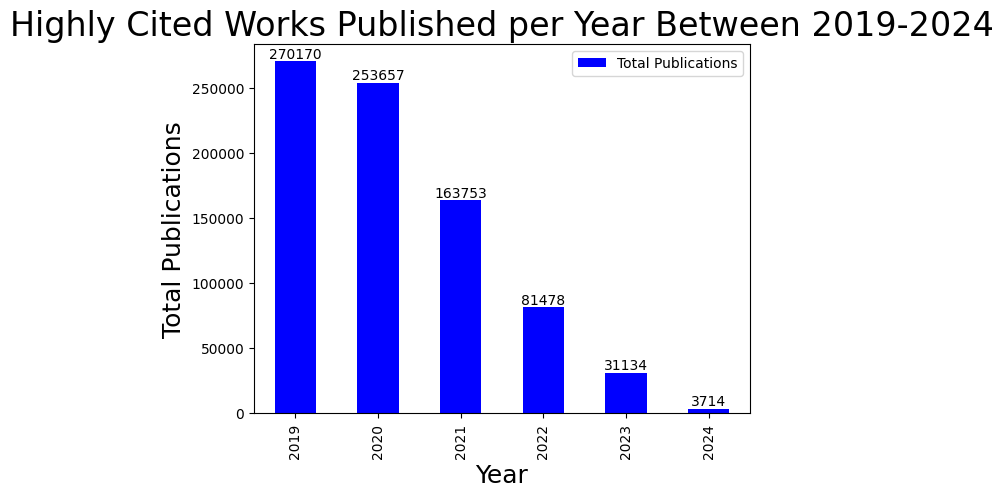

In [36]:
# Plot the total number of highly cited works published that year
hc_works_by_year = hc_works_per_year.plot.bar(color='blue')

# Title and label the graph as approprite
hc_works_by_year.set_title(label='Highly Cited Works Published per Year Between 2019-2024', fontsize=24, color='black')
hc_works_by_year.set_xlabel('Year', fontsize=18, color='black')
hc_works_by_year.set_ylabel('Total Publications', fontsize=18, color='black')
hc_works_by_year.legend(['Total Publications'])

# Annotate the bars, put them in decimal format
hc_works_by_year.bar_label(hc_works_by_year.containers[0], fmt='%d', label_type='edge', color='black')

For each year 2019-2024, these are the amounts of "highly cited" works that were published that year. A majority of the data comes from the years 2019-2021 because these works have been out for longer than the ones in 2022-2024, so they had more time to get more citations.

# Which Institutions are Publishing All These Highly Cited Works?

In [13]:
# Find the total number of highly cited works published by institution between 2019-2024
total_publications = (
    works_institutions_df

    # Group publication counts by institution ID in the event of duplicate names
    .groupby('institution_id')
    .agg(

        # Look at the first occurrence of the institution name
        institution=('institution_name', 'first'),

        # Number of unique work IDs per institution is the amount they published
        total_publications=('work_id', 'nunique'),
    )
        
     # Sort by total publication count in descending order
    .sort_values(by='total_publications', ascending=False)
)

In [14]:
display(total_publications.head())

,institution,total_publications
institution_id,,
19820366,Chinese Academy of Sciences,40696
1294671590,Centre National de la Recherche Scientifique,17541
124357947,University of London,17177
136199984,Harvard University,16164
4210165038,University of Chinese Academy of Sciences,14125


[Text(0, 0, '40696'),
 Text(0, 0, '17541'),
 Text(0, 0, '17177'),
 Text(0, 0, '16164'),
 Text(0, 0, '14125'),
 Text(0, 0, '11530'),
 Text(0, 0, '10652'),
 Text(0, 0, '10369'),
 Text(0, 0, '9503'),
 Text(0, 0, '9318')]

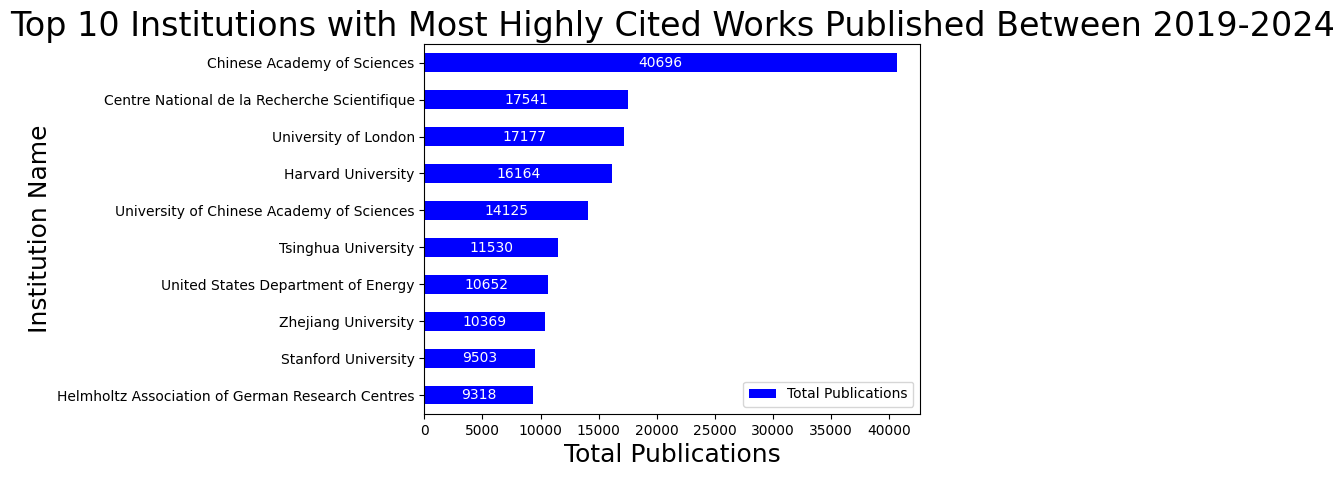

In [15]:
# Plot the top ten institutions with most highly cited works published 
# Dataframe is sorted, first 10 rows will have the most highly cited works published
ten_most_published = total_publications.head(10).plot.barh(
    x='institution',
    y='total_publications',
    color='blue'
)

# Title and label the graph as approprite
ten_most_published.set_title(label='Top 10 Institutions with Most Highly Cited Works Published Between 2019-2024', fontsize=24, color='black')
ten_most_published.set_xlabel('Total Publications', fontsize=18, color='black')
ten_most_published.set_ylabel('Institution Name', fontsize=18, color='black')
ten_most_published.legend(['Total Publications'])

# Invert the y-axis to sort the bars in descending order
ten_most_published.invert_yaxis()

# Annotate the bars, put them in decimal format
ten_most_published.bar_label(ten_most_published.containers[0], fmt='%d', label_type='center', color='white')

These ten institutions have the most highly cited works published between the years 2019-2024. Many of these are world-renowned national or private institutions with massive research budgets.

# For All Highly Cited Works Published in this Era, Which Institutions Receive the Most Citations Across their Highly Cited Works?

In [16]:
# Find the total number of citations among all works published by an institution
total_citations = (
    works_institutions_df

    # Group citation counts by institution ID in the event of duplicate names
    .groupby('institution_id')
    .agg(

        # Look at the first occurrence of the institution name
        institution=('institution_name', 'first'),

        # Sum up total citation counts for each institution across all of their highly cited published works
        total_citations=('cited_by_count', 'sum'),
    )
        
     # Sort by total citation count in descending order
    .sort_values(by='total_citations', ascending=False)
)

In [17]:
display(total_citations)

,institution,total_citations
institution_id,,
19820366,Chinese Academy of Sciences,4836906
124357947,University of London,2423491
136199984,Harvard University,2358550
1294671590,Centre National de la Recherche Scientifique,2082424
4210165038,University of Chinese Academy of Sciences,1631559
...,...,...
135038448,Higher Institute of Technologies and Applied Sciences,50
4210108878,Yokohama Rubber (Japan),50
3129536290,Klabat University,50


[Text(0, 0, '4836906'),
 Text(0, 0, '2423491'),
 Text(0, 0, '2358550'),
 Text(0, 0, '2082424'),
 Text(0, 0, '1631559'),
 Text(0, 0, '1523720'),
 Text(0, 0, '1453137'),
 Text(0, 0, '1443292'),
 Text(0, 0, '1320583'),
 Text(0, 0, '1237485')]

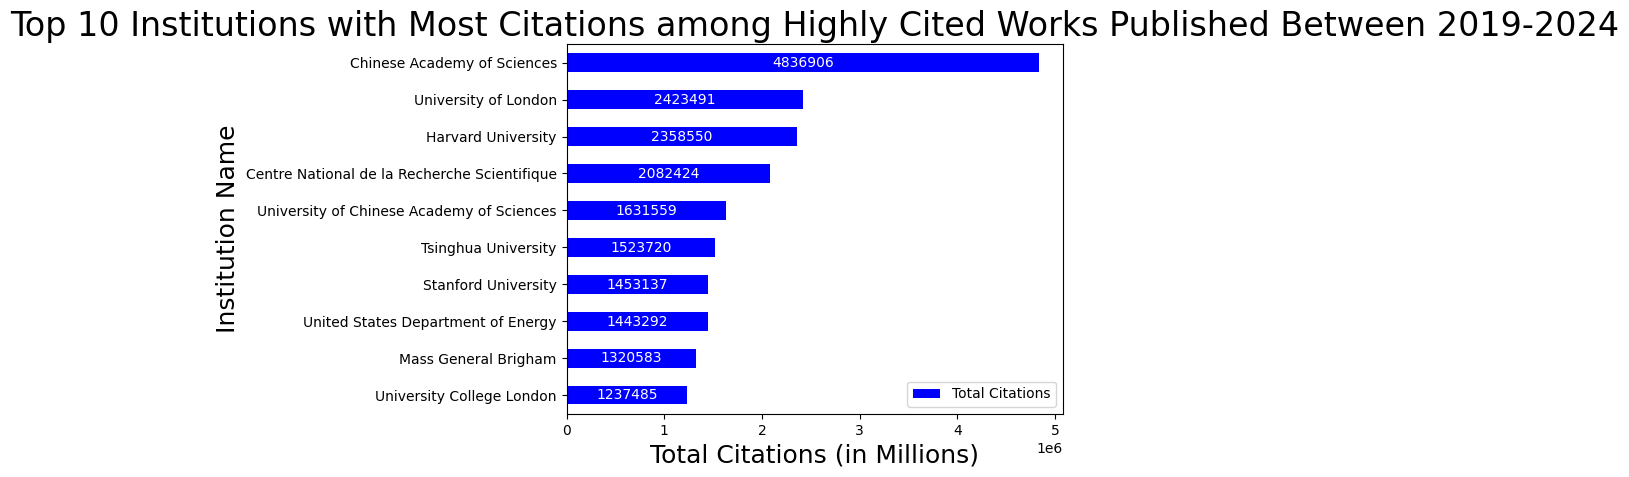

In [19]:
# Plot the top ten institutions with most citations across works published
# Dataframe is sorted, first 10 rows will have the most citations
ten_most_cited = total_citations.head(10).plot.barh(
    x='institution',
    y='total_citations',
    color='blue'
)

# Title and label the graph as approprite
ten_most_cited.set_title(label='Top 10 Institutions with Most Citations among Highly Cited Works Published Between 2019-2024', fontsize=24, color='black')
ten_most_cited.set_xlabel('Total Citations (in Millions)', fontsize=18, color='black')
ten_most_cited.set_ylabel('Institution Name', fontsize=18, color='black')
ten_most_cited.legend(['Total Citations'])

# Invert the y-axis to sort the bars in descending order
ten_most_cited.invert_yaxis()

# Annotate the bars, put them in decimal format
ten_most_cited.bar_label(ten_most_cited.containers[0], fmt='%d', label_type='center', color='white')

These ten institutions received the most citations across all of their highly cited works published between 2019-2024. There is a lot of overlap with the table "Top 10 Institutions with Most Highly Cited Works Published Between 2019-2024" suggesting that the sheer volume of works published by these institutions inflates their citation counts.

# Co-Authorship Patterns among Institutions Publishing Highly Cited Works

Given the institutions that publish most of the highly cited works, do they collaborate with each other often or do they tend to stay within their own bubble?

## Mapping Institution IDs

In [5]:
# Map an institution ID to its name 
institution_map = (
    works_institutions_df
    .groupby('institution_id')['institution_name']
    .agg(lambda x: x.mode().iloc[0])
    .to_dict()
)

# Preview mapping entries
print(f"Institution map: {len(institution_map):,} entries")
print("\nSample entries:")
for iid, name in list(institution_map.items())[:5]:
    print(f"{iid} → {name}")

Institution map: 45,062 entries

Sample entries:
9507 → Sangji University
19722 → Ateneo de Manila University
41870 → Military Institute of Engineering
43886 → Sapientia Hungarian University of Transylvania
46017 → Kahramanmaraş Sütçü İmam University


## Building Transactions

In [6]:
# Group each work ID to a set of institution IDs
# A transaction is the set of institution IDs associated with a highly cited work ID
work_institutions = (
    works_institutions_df
    .groupby('work_id')['institution_id']
    .apply(set)
)

# Convert to a list of lists for mlxtend
transactions = [list(institutions) for institutions in work_institutions]

# Preview the first transaction
sample_work  = work_institutions.index[0]
sample_ids   = transactions[0]
sample_names = [institution_map.get(i, 'Unknown') for i in sample_ids]
print(f"\nSample transaction (Work ID: {sample_work})")
print(f"Associated institution ID(s) : {sample_ids}")
print(f"Name(s)                      : {sample_names}")


Sample transaction (Work ID: 665341)
Associated institution ID(s) : [np.int64(99065089)]
Name(s)                      : ['Tsinghua University']


In [7]:
# Since this project explores all topics, much more data to load so use a sample to prevent kernel crashes
# The largest viable sample size I could successfully use was 50,000
SAMPLE_SIZE = 50000

# Fix the seed so re-running this cell gives the same sample
random.seed(2026)
if len(transactions) > SAMPLE_SIZE:
    transactions = random.sample(transactions, SAMPLE_SIZE)

## Constructing TransactionEncoder (for Apriori)

In [8]:
# Converts the transaction matrix into a one-hot encoded dataframe
# Required input format for Apriori to run
te = TransactionEncoder()

# Use fit_transform to learn the full item univerise, then encode each transaction
te_array = te.fit_transform(transactions)

# Construct a dataframe from the encoded matrix where columns represent institution IDs
te_df = pd.DataFrame(te_array, columns=te.columns_)

# Display the dimensions of the te matrix
print(f"Encoded matrix shape: {te_df.shape}")
print(f"{te_df.shape[0]:,} rows  (works / transactions)")
print(f"{te_df.shape[1]:,} cols  (unique institutions / items)")

# Display the sparsity of the matrix
sparsity = (~te_df).sum().sum() / te_df.size
print(f"\nSparsity: {sparsity:.2%} of values are False")

te_df.head()

Encoded matrix shape: (50000, 18896)
50,000 rows  (works / transactions)
18,896 cols  (unique institutions / items)

Sparsity: 99.98% of values are False


,9507,41870,46017,47844,52325,80043,189991,215927,226432,241749,...,4407990181,4407990293,4407990318,4407990416,4407990431,4408541744,4408542113,4408895851,4410514724,4410514767
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
# Detect names shared by more than one institution ID
name_counts = pd.Series(institution_map.values()).value_counts()
duplicate_iids = set(name_counts[name_counts > 1].index)

# Build display label to differentiate institutions that share the same name
# Will be plain if the name is unique, in the format "Name [id]" if shared
institution_display_map = {
    iid: (f"{name} [{iid}]" if name in duplicate_iids else name)
    for iid, name in institution_map.items()
}

# Label the transaction encoder dataframe using the display map
labeled_te_df = te_df.rename(columns=institution_display_map)

labeled_te_df.head()

,Sangji University,Military Institute of Engineering,Kahramanmaraş Sütçü İmam University,Al Akhawayn University,Fundação Oswaldo Cruz,Institut Curie,"University of Veterinary Medicine Hannover, Foundation",University of Madras,Universiti Malaysia Kelantan,University of Cambridge,...,SAnté INgenierie BIOlogie Saint-Etienne,Université Marie et Louis Pasteur,Indiana University Columbus,U.S. Army Materiel Command,Université Bourgogne Europe,United States Space Command,Region Jämtland Härjedalen,Sistema Nazionale per la Protezione dell'Ambiente,Government of the Republic of China,Stichting Aeres Groep
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Apriori Search

In [10]:
# Testing five different min support thresholds: 
# institutions appearing in 0.2375% (the lowest I could run without crashing), 
# 0.3%, 0.35%, 0.4%, and 0.45% of papers respectively
min_supports = [0.002375, 0.003, 0.0035, 0.004, 0.0045]
counts = []
for ms in min_supports:
    fi = apriori(labeled_te_df, min_support=ms, use_colnames=True, verbose=0)

    # Append the length of each set of frequent itemsets to the list counts
    counts.append(len(fi))

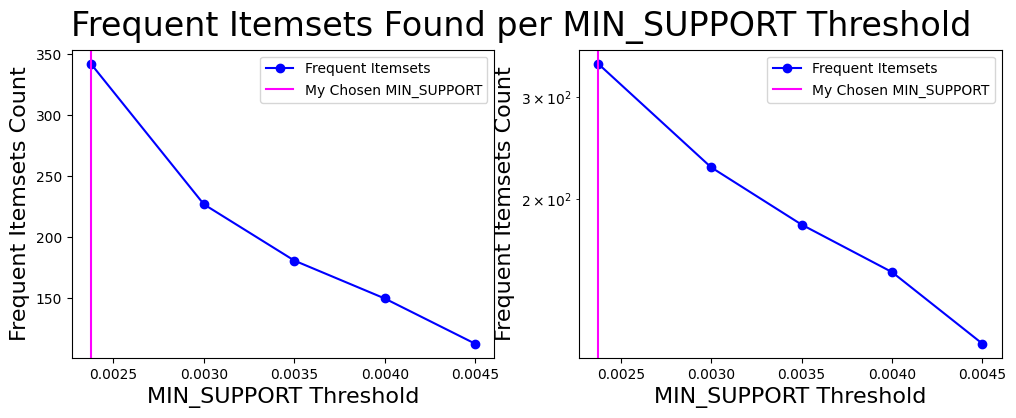

In [11]:
# Convert the array data obtained from the Apriori search to dataframes for plotting
min_supports_df = pd.DataFrame(min_supports, columns=["MIN_SUPPORT"])
counts_df = pd.DataFrame(counts, columns=["Frequent Itemsets"])

# Construct a temporary dataframe combining the information for the minimum support
# and frequent itemsets counts to plot
min_supports_to_itemsets = pd.concat([min_supports_df, counts_df], axis=1)

# Construct two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Set a single title for both plots
fig.suptitle('Frequent Itemsets Found per MIN_SUPPORT Threshold', fontsize=24, color='black')

# Plot the combined dataframe on the left panel
ax1 = min_supports_to_itemsets.plot(x='MIN_SUPPORT', y='Frequent Itemsets', ax=ax1, color='blue', marker='o')

# Label the axes as appropriate
ax1.set_xlabel('MIN_SUPPORT Threshold', fontsize=16, color='black')
ax1.set_ylabel('Frequent Itemsets Count', fontsize=16, color='black')

# Add a vertical line annotation on the left panel for my chosen MIN_SUPPORT threshold
ax1.axvline(x=0.002375, color='magenta')

# Add a legend to the left panel to annotate the graph line and chosen MIN_SUPPORT threshold
ax1.legend(['Frequent Itemsets', 'My Chosen MIN_SUPPORT'])

# Plot the combined dataframe on the right panel
ax2 = min_supports_to_itemsets.plot(x='MIN_SUPPORT', y='Frequent Itemsets', ax=ax2, color='blue', marker='o')

# Label the axes as appropriate
ax2.set_xlabel('MIN_SUPPORT Threshold', fontsize=16, color='black')
ax2.set_ylabel('Frequent Itemsets Count', fontsize=16, color='black')

# Convert the right panel to a logarithmic axis
ax2.set_yscale('log')

# Add a vertical line annotation on the right panel for my chosen MIN_SUPPORT threshold
ax2.axvline(x=0.002375, color='magenta')

# Add a legend to the right panel to annotate the graph line and chosen MIN_SUPPORT threshold
ax2.legend(['Frequent Itemsets', 'My Chosen MIN_SUPPORT'])

Visualizes the total number of frequent itemsets plotted at each tested MIN_SUPPORT threshold. The vertical magenta line represents the MIN_SUPPORT threshold I chose for this analysis. My chosen MIN_SUPPORT threshold states that the authoring institution(s) appear in at least 0.2375% of all papers within the dataset. This chosen MIN_SUPPORT threshold yields 342 frequent itemsets, which is slightly above the middle of the recommended 100-500 frequent itemsets.

In [12]:
# Institution pair appears in at least 0.2375% of papers
MIN_SUPPORT = 0.002375

# Run the Apriori search at MIN_SUPPORT threshold 0.002375
print(f"Running Apriori at min_support threshold {MIN_SUPPORT}")
frequent_itemsets = apriori(
    labeled_te_df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=None,
    verbose=1,
)

# Sort found frequent itemsets by support
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print(f"There are {len(frequent_itemsets):,} frequent itemsets at MIN_SUPPORT threshold {MIN_SUPPORT}")

display(frequent_itemsets.head())

Running Apriori at min_support threshold 0.002375
Processing 5 combinations | Sampling itemset size 5 432
There are 342 frequent itemsets at MIN_SUPPORT threshold 0.002375


,support,itemsets
17,0.04932,frozenset({Chinese Academy of Sciences})
209,0.02236,frozenset({Centre National de la Recherche Scientifique})
109,0.02044,frozenset({University of London})
121,0.01948,frozenset({Harvard University})
263,0.01728,"frozenset({University of Chinese Academy of Sciences, Chinese Academy of Sci..."


In [13]:
# Add itemset length column for easy filtering
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

# Display the proportion of frequent itemsets found for each size
print("Frequent itemsets found by size:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

Frequent itemsets found by size:
length
1    259
2     59
3     18
4      5
5      1


## Most Frequent Solo Institutions Publishing Highly Cited Works from 2019-2024?

In [17]:
print("Most frequent solo institutions publishing highly cited works between 2019-2024:")
freq_insts = (
    
    # Filter to find the most frequent 1-itemsets
    frequent_itemsets[frequent_itemsets['length'] == 1]
    [['support', 'itemsets']]
)

display(freq_insts.head())

Most frequent solo institutions publishing highly cited works between 2019-2024:


,support,itemsets
17,0.04932,frozenset({Chinese Academy of Sciences})
209,0.02236,frozenset({Centre National de la Recherche Scientifique})
109,0.02044,frozenset({University of London})
121,0.01948,frozenset({Harvard University})
253,0.01728,frozenset({University of Chinese Academy of Sciences})


[Text(0, 0, '0.049320'),
 Text(0, 0, '0.022360'),
 Text(0, 0, '0.020440'),
 Text(0, 0, '0.019480'),
 Text(0, 0, '0.017280'),
 Text(0, 0, '0.013900'),
 Text(0, 0, '0.012980'),
 Text(0, 0, '0.012780'),
 Text(0, 0, '0.012200'),
 Text(0, 0, '0.011760')]

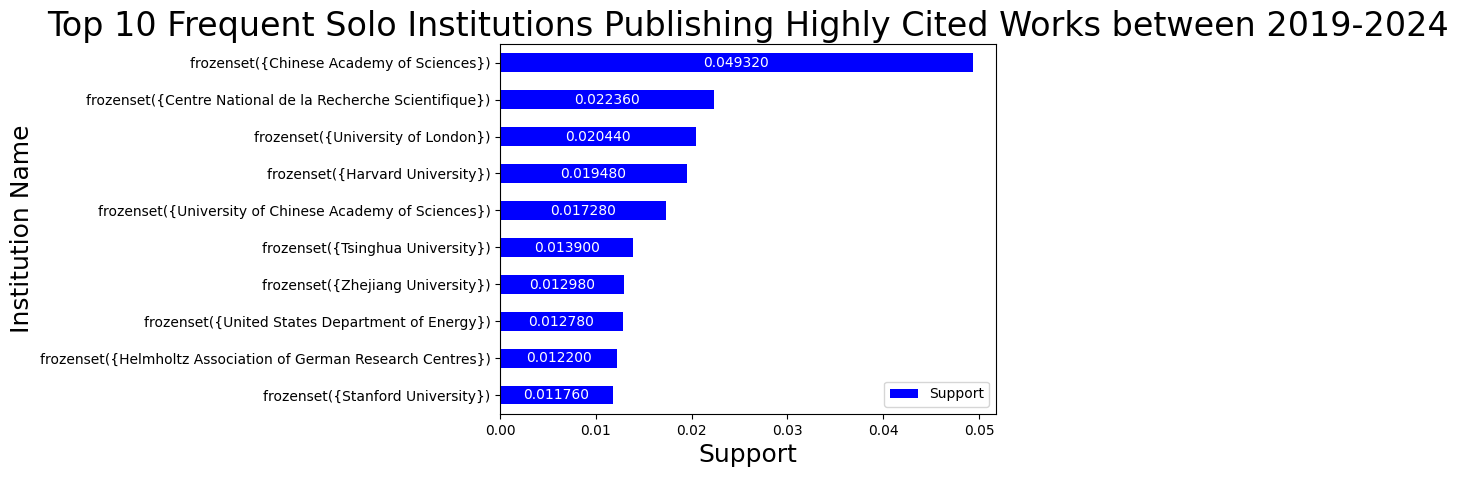

In [35]:
# Sort by support in descending order
freq_insts = freq_insts.sort_values(by='support', ascending=False)

# Plot the top ten frequent solo institutions by support
# Dataframe is sorted, first 10 rows will have the highest support
top_ten_freq_insts = freq_insts.head(10).plot.barh(
    x='itemsets',
    y='support',
    color='blue'
)

# Title and label the graph as approprite
top_ten_freq_insts.set_title(label='Top 10 Frequent Solo Institutions Publishing Highly Cited Works between 2019-2024', fontsize=24, color='black')
top_ten_freq_insts.set_xlabel('Support', fontsize=18, color='black')
top_ten_freq_insts.set_ylabel('Institution Name', fontsize=18, color='black')
top_ten_freq_insts.legend(['Support'])

# Invert the y-axis to sort the bars in descending order
top_ten_freq_insts.invert_yaxis()

# Annotate the bars
top_ten_freq_insts.bar_label(top_ten_freq_insts.containers[0], fmt='%f', label_type='center', color='white')

These are the top ten institutions solo publishing highly cited works between 2019-2024 with the highest support. There is a lot of overlap with the table "Top 10 Institutions with Most Highly Cited Works Published Between 2019-2024" which makes sense as this measures the proportion of highly cited works found by institution in the sample.

# Most Frequent Pairs of Institutions Co-Authoring Highly Cited Works from 2019-2024?

In [16]:
print("Most frequent pairs of institutions publishing highly cited works between 2019-2024:")
freq_inst_pairs = (
    
    # Filter to find the most frequent 2-itemsets
    frequent_itemsets[frequent_itemsets['length'] == 2]
    [['support', 'itemsets']]
)

display(freq_inst_pairs.head())

Most frequent pairs of institutions publishing highly cited works between 2019-2024:


,support,itemsets
263,0.01728,"frozenset({University of Chinese Academy of Sciences, Chinese Academy of Sci..."
268,0.01008,"frozenset({University College London, University of London})"
266,0.00994,"frozenset({Office of Science, United States Department of Energy})"
269,0.00816,"frozenset({Harvard University, Mass General Brigham})"
301,0.00806,"frozenset({United States Department of Health and Human Services, National I..."


[Text(0, 0, '0.017280'),
 Text(0, 0, '0.010080'),
 Text(0, 0, '0.009940'),
 Text(0, 0, '0.008160'),
 Text(0, 0, '0.008060'),
 Text(0, 0, '0.007980'),
 Text(0, 0, '0.006140'),
 Text(0, 0, '0.006020'),
 Text(0, 0, '0.005980'),
 Text(0, 0, '0.005560')]

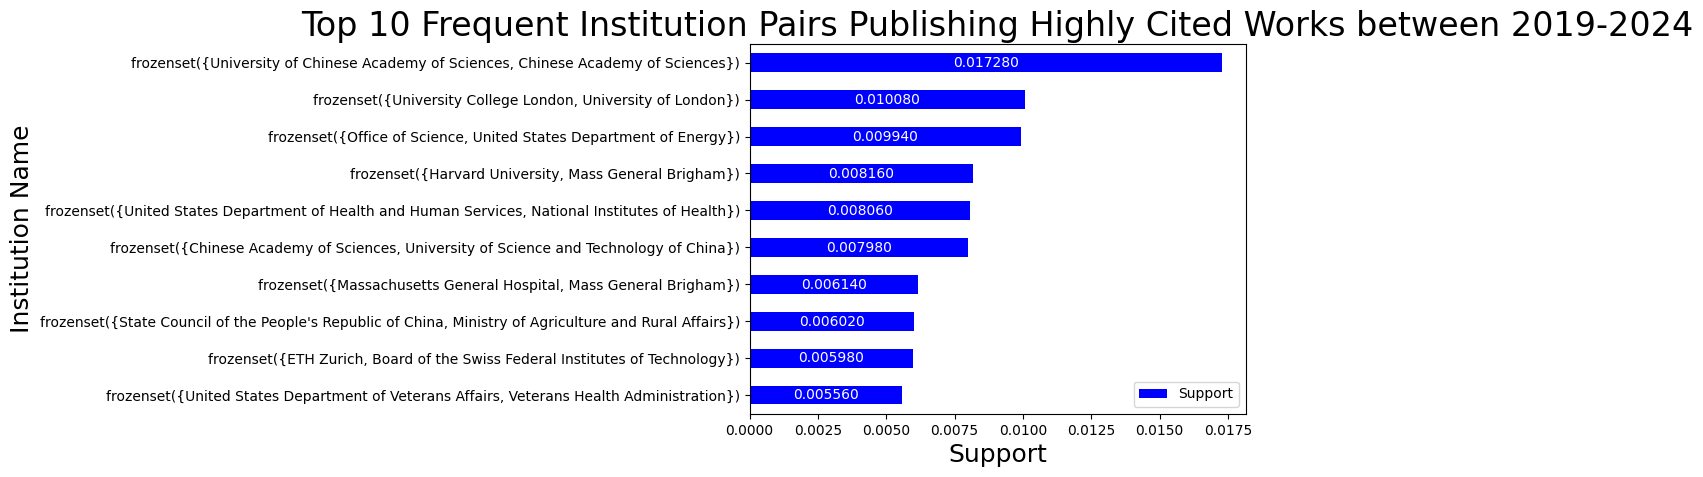

In [19]:
# Sort by support in descending order
freq_inst_pairs = freq_inst_pairs.sort_values(by='support', ascending=False)

# Plot the top ten pairs of institutions by support
# Dataframe is sorted, first 10 rows will have the highest support
top_ten_pairs = freq_inst_pairs.head(10).plot.barh(
    x='itemsets',
    y='support',
    color='blue'
)

# Title and label the graph as approprite
top_ten_pairs.set_title(label='Top 10 Frequent Institution Pairs Publishing Highly Cited Works between 2019-2024', fontsize=24, color='black')
top_ten_pairs.set_xlabel('Support', fontsize=18, color='black')
top_ten_pairs.set_ylabel('Institution Name', fontsize=18, color='black')
top_ten_pairs.legend(['Support'])

# Invert the y-axis to sort the bars in descending order
top_ten_pairs.invert_yaxis()

# Annotate the bars
top_ten_pairs.bar_label(top_ten_pairs.containers[0], fmt='%f', label_type='center', color='white')

These are the top ten institutions publishing highly cited works in pairs between the years 2019-2024. There is less overlap with the top ten solo institutions publishing highly cited works which suggests that some of these institutions act independently. Additionally, among the institutions that publish together, there seems to be a preference to stay local as there does not seem to be a lot of international collaboration. A lot of these institutions are publishing with local federal institutions or their subsidiaries. There also seems to be a lot of federal institutions publishing together.

#  Most Frequent Groups of Institutions Co-Authoring Highly Cited Works from 2019-2024?

When I refer to a "group," I mean a collaboration between institutions with **more than two** co-authors.

In [20]:
print("Most frequent groups of institutions publishing highly cited works between 2019-2024:")
freq_inst_groups = (
    
    # Filter to find the most frequent n-itemsets where n > 2
    frequent_itemsets[frequent_itemsets['length'] > 2]
    [['support', 'itemsets']]
)

display(freq_inst_groups.head())

Most frequent groups of institutions publishing highly cited works between 2019-2024:


,support,itemsets
320,0.00480,"frozenset({Massachusetts General Hospital, Harvard University, Mass General ..."
323,0.00436,"frozenset({Commonwealth Scientific and Industrial Research Organisation, Aus..."
319,0.00424,"frozenset({Harvard University, Brigham and Women's Hospital, Mass General Br..."
335,0.00370,"frozenset({State Council of the People's Republic of China, Ministry of Agri..."
318,0.00304,"frozenset({Lawrence Berkeley National Laboratory, Office of Science, United ..."


[Text(0, 0, '0.004800'),
 Text(0, 0, '0.004360'),
 Text(0, 0, '0.004240'),
 Text(0, 0, '0.003700'),
 Text(0, 0, '0.003040'),
 Text(0, 0, '0.002940'),
 Text(0, 0, '0.002820'),
 Text(0, 0, '0.002820'),
 Text(0, 0, '0.002820'),
 Text(0, 0, '0.002820')]

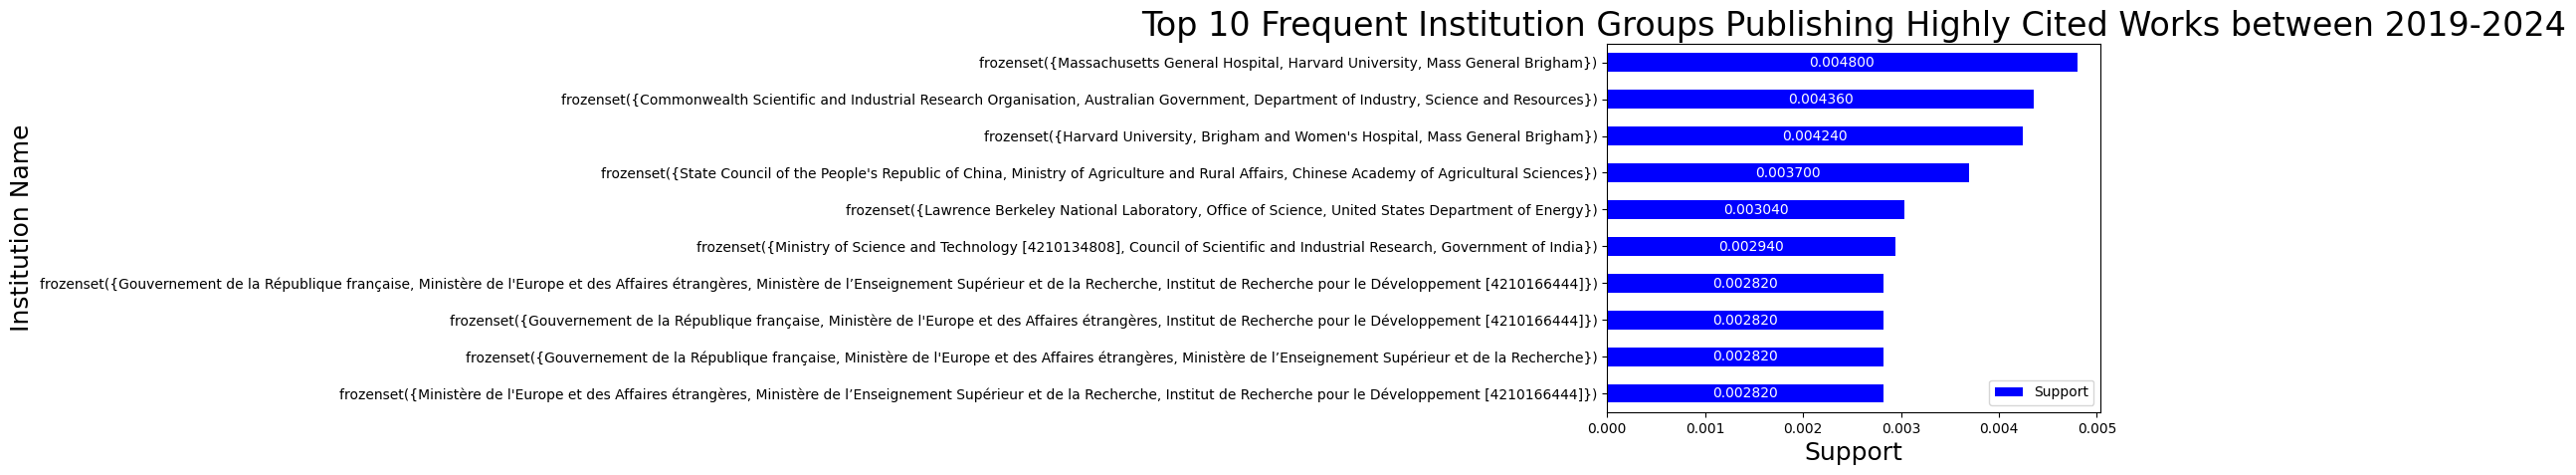

In [22]:
# Sort by support in descending order
freq_inst_groups = freq_inst_groups.sort_values(by='support', ascending=False)

# Plot the top ten groups of institutions by support
# Dataframe is sorted, first 10 rows will have the highest support
top_ten_groups = freq_inst_groups.head(10).plot.barh(
    x='itemsets',
    y='support',
    color='blue'
)

# Title and label the graph as approprite
top_ten_groups.set_title(label='Top 10 Frequent Institution Groups Publishing Highly Cited Works between 2019-2024', fontsize=24, color='black')
top_ten_groups.set_xlabel('Support', fontsize=18, color='black')
top_ten_groups.set_ylabel('Institution Name', fontsize=18, color='black')
top_ten_groups.legend(['Support'])

# Invert the y-axis to sort the bars in descending order
top_ten_groups.invert_yaxis()

# Annotate the bars
top_ten_groups.bar_label(top_ten_groups.containers[0], fmt='%f', label_type='center', color='white')

These are the top ten institutions publishing highly cited works in groups **larger than two** between the years 2019-2024. Similar to the results for frequent pairs of institutions, there is less overlap with the top ten solo institutions publishing highly cited works which suggests that some of these institutions act independently. Additionally, among the institutions that publish together, there seems to be a preference to stay local as there does not seem to be a lot of international collaboration. A lot of these institutions are publishing with local federal institutions or their subsidiaries. Here, there seems to be more groups of federal institutions publishing together.

## Generating Association Rules

In [23]:
# Generate rules using Kulczynski as primary means of evaluation, a symmetric measure.
rules_df = association_rules(
    frequent_itemsets,
    metric='kulczynski',
    
    # Only interested in rules with moderate symmetry between conditional probabilities
    min_threshold=0.3,
    num_itemsets=len(frequent_itemsets),
)

print(f"Generated {len(rules_df):,} association rules")
rules_df.sort_values(by='kulczynski', ascending=False).head()

Generated 324 association rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
143,"frozenset({Gouvernement de la République française, Ministère de l'Europe et...",frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.00282,0.00282,0.00282,1.0,354.609929,1.0,0.002812,inf,1.0,1.0,1.0,1.0
128,"frozenset({Ministère de l'Europe et des Affaires étrangères, Institut de Rec...","frozenset({Gouvernement de la République française, Ministère de l’Enseignem...",0.00282,0.00282,0.00282,1.0,354.609929,1.0,0.002812,inf,1.0,1.0,1.0,1.0
138,"frozenset({Gouvernement de la République française, Ministère de l'Europe et...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.00282,0.00282,0.00282,1.0,354.609929,1.0,0.002812,inf,1.0,1.0,1.0,1.0
139,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Gouvernement de la République française, Ministère de l'Europe et...",0.00282,0.00282,0.00282,1.0,354.609929,1.0,0.002812,inf,1.0,1.0,1.0,1.0
141,frozenset({Ministère de l'Europe et des Affaires étrangères}),"frozenset({Gouvernement de la République française, Institut de Recherche po...",0.00282,0.00282,0.00282,1.0,354.609929,1.0,0.002812,inf,1.0,1.0,1.0,1.0


I chose Kulczynski as my primary means of assessing rules because direction does not matter here but symmetry does. For example, if Harvard and Yale wrote a paper together it does not matter which one comes first as they are both associated with the work. For my secondary means of evaluation, I am looking at Jaccard similarity and lift. Jaccard similarity, like Kulczynski, is also a symmetric measure. It measures the similarity between two sets, but penalizes rare items that might have important information, which is why I chose Kulczynski as my primary means of evaluation. I use lift as a sanity check to see how much more likely this pair is to occur together than by random chance. The relationship needs to be symmetric to ensure that the institutions in question are actually publishing together. A one-sided relationship between institutions would make no sense.

# Helper Functions for Rule Mining

In [34]:
def rules_involving(rules_df, label, side='either'):
    """
    Filter rules that involve a specific author display label.

    Parameters
    ----------
    rules_df : association rules DataFrame
    label    : str — the author display label (from author_display_map)
    side     : 'antecedent' | 'consequent' | 'either'
    """
    in_ant = rules_df['antecedents'].apply(lambda x: label in x)
    in_con = rules_df['consequents'].apply(lambda x: label in x)

    if side == 'antecedent':
        mask = in_ant
    elif side == 'consequent':
        mask = in_con
    else:
        mask = in_ant | in_con

    return rules_df[mask].sort_values('lift', ascending=False)


def rules_with_antecedent_size(rules_df, size):
    """Filter rules where the antecedent has exactly `size` items."""
    return rules_df[rules_df['antecedents'].apply(len) == size]

# Recycled from rules_with_antecedent_size to help with some of my searches
def rules_with_min_antecedent_size(rules_df, size):
    """Filter rules where the antecedent has at least `size` items."""
    return rules_df[rules_df['antecedents'].apply(len) >= size]


def rules_above_thresholds(rules_df, min_confidence=0.5, min_lift=2.0):
    """Filter rules meeting both confidence and lift thresholds."""
    return rules_df[
        (rules_df['confidence'] >= min_confidence) &
        (rules_df['lift']       >= min_lift)
    ]


def fmt_set(s):
    """Render a frozenset of author labels as a readable string."""
    return ', '.join(sorted(str(x) for x in s))

print("Helper functions defined ✅")

Helper functions defined ✅


# Filtering Rules for Institution Combinations

## 1-1 Relationships

**"If institution A wrote this work, institution B also likely helped co-author this work"**

In [35]:
# Rules with a single-instutution antecedent and single-institution consequent
inst_1_to_1_rules = (

    # Filter for antecedent size of 1
    rules_with_antecedent_size(rules_df, 1)

    # Filter for consequent size of 1
    .pipe(lambda df: df[df['consequents'].apply(len) == 1])

    # Sort by Kulczynski to ensure symmetry
    .sort_values(by='kulczynski', ascending=False)
)

print(f"1-institution antecedent → 1-institution consequent: {len(inst_1_to_1_rules)} rules")
inst_1_to_1_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head(10)

1-institution antecedent → 1-institution consequent: 116 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
161,frozenset({Institut de Recherche pour le Développement [4210166444]}),frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.00282,1.0,354.609929,1.0,1.0
160,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),frozenset({Institut de Recherche pour le Développement [4210166444]}),0.00282,1.0,354.609929,1.0,1.0
107,frozenset({Indiana University}),frozenset({Indiana University Columbus}),0.00298,1.0,335.570470,1.0,1.0
106,frozenset({Indiana University Columbus}),frozenset({Indiana University}),0.00298,1.0,335.570470,1.0,1.0
149,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),frozenset({Ministère de l'Europe et des Affaires étrangères}),0.00282,1.0,354.609929,1.0,1.0
148,frozenset({Ministère de l'Europe et des Affaires étrangères}),frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.00282,1.0,354.609929,1.0,1.0
152,frozenset({Ministère de l'Europe et des Affaires étrangères}),frozenset({Institut de Recherche pour le Développement [4210166444]}),0.00282,1.0,354.609929,1.0,1.0
153,frozenset({Institut de Recherche pour le Développement [4210166444]}),frozenset({Ministère de l'Europe et des Affaires étrangères}),0.00282,1.0,354.609929,1.0,1.0
182,frozenset({Harris Health System}),frozenset({Baylor College of Medicine}),0.00264,1.0,378.787879,1.0,1.0
183,frozenset({Baylor College of Medicine}),frozenset({Harris Health System}),0.00264,1.0,378.787879,1.0,1.0


Similar to the pairs and groups of frequent institutions publishing together, a lot of these institutions publishing these highly cited works prefer to stay local. There are three main patterns here: federal institutions collaborating, universities collaborating with their satellite campuses, and institutions collaborating with their partners and subsidiaries. 

## 1-N Relationships

**"If institution A wrote this work, institutions B and C also likely helped co-author this work"**

In [36]:
# Rules with a single-instutution antecedent and n-institution consequent
inst_1_to_n_rules = (

    # Filter for antecedent size of 1
    rules_with_antecedent_size(rules_df, 1)

    # Filter for consequent size larger than 1
    .pipe(lambda df: df[df['consequents'].apply(len) > 1])

    # Sort by Kulczynski to ensure symmetry
    .sort_values(by='kulczynski', ascending=False)
)

print(f"1-institution antecedent → n-institution consequent: {len(inst_1_to_n_rules)} rules")
inst_1_to_n_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head(10)

1-institution antecedent → n-institution consequent: 79 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
146,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),"frozenset({Gouvernement de la République française, Ministère de l'Europe et...",0.00282,1.0,354.609929,1.0,1.0
157,frozenset({Ministère de l'Europe et des Affaires étrangères}),"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Institu...",0.00282,1.0,354.609929,1.0,1.0
147,frozenset({Ministère de l'Europe et des Affaires étrangères}),"frozenset({Gouvernement de la République française, Ministère de l’Enseignem...",0.00282,1.0,354.609929,1.0,1.0
170,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),"frozenset({Gouvernement de la République française, Institut de Recherche po...",0.00282,1.0,354.609929,1.0,1.0
171,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Gouvernement de la République française, Ministère de l’Enseignem...",0.00282,1.0,354.609929,1.0,1.0
159,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Ministère de l'Europe et des Affaires étrangères, Ministère de l’...",0.00282,1.0,354.609929,1.0,1.0
158,frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),"frozenset({Ministère de l'Europe et des Affaires étrangères, Institut de Rec...",0.00282,1.0,354.609929,1.0,1.0
141,frozenset({Ministère de l'Europe et des Affaires étrangères}),"frozenset({Gouvernement de la République française, Institut de Recherche po...",0.00282,1.0,354.609929,1.0,1.0
135,frozenset({Ministère de l'Europe et des Affaires étrangères}),"frozenset({Gouvernement de la République française, Ministère de l’Enseignem...",0.00282,1.0,354.609929,1.0,1.0
139,frozenset({Institut de Recherche pour le Développement [4210166444]}),"frozenset({Gouvernement de la République française, Ministère de l'Europe et...",0.00282,1.0,354.609929,1.0,1.0


When it comes to groups of institutions larger than two, a majority of these groupings are various federal institutions collaborating with each other. France's federal research institutes are the largest in continental Europe, so they seem to have a monopoly on research for the Francophone world.

## N-1 Relationships

**"If institutions A and B wrote this work together, institution C also likely helped co-author this work"**

In [37]:
# Rules with an n-instutution antecedent and single-institution consequent
inst_n_to_1_rules = (

    # See helper functions
    # Filter for antecedent size larger than 1
    rules_with_min_antecedent_size(rules_df, 2)

    # Filter for consequent size of 1
    .pipe(lambda df: df[df['consequents'].apply(len) == 1])

    # Sort by Kulczynski to ensure symmetry
    .sort_values(by='kulczynski', ascending=False)
)

print(f"n-institution antecedent → 1-institution consequent: {len(inst_n_to_1_rules)} rules")
inst_n_to_1_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']].head(10)

n-institution antecedent → 1-institution consequent: 79 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
142,"frozenset({Gouvernement de la République française, Ministère de l’Enseignem...",frozenset({Ministère de l'Europe et des Affaires étrangères}),0.00282,1.0,354.609929,1.0,1.0
143,"frozenset({Gouvernement de la République française, Ministère de l'Europe et...",frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.00282,1.0,354.609929,1.0,1.0
154,"frozenset({Ministère de l'Europe et des Affaires étrangères, Ministère de l’...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.00282,1.0,354.609929,1.0,1.0
166,"frozenset({Gouvernement de la République française, Ministère de l’Enseignem...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.00282,1.0,354.609929,1.0,1.0
167,"frozenset({Gouvernement de la République française, Institut de Recherche po...",frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.00282,1.0,354.609929,1.0,1.0
155,"frozenset({Ministère de l'Europe et des Affaires étrangères, Institut de Rec...",frozenset({Ministère de l’Enseignement Supérieur et de la Recherche}),0.00282,1.0,354.609929,1.0,1.0
156,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Institu...",frozenset({Ministère de l'Europe et des Affaires étrangères}),0.00282,1.0,354.609929,1.0,1.0
138,"frozenset({Gouvernement de la République française, Ministère de l'Europe et...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.00282,1.0,354.609929,1.0,1.0
125,"frozenset({Gouvernement de la République française, Ministère de l’Enseignem...",frozenset({Institut de Recherche pour le Développement [4210166444]}),0.00282,1.0,354.609929,1.0,1.0
136,"frozenset({Gouvernement de la République française, Institut de Recherche po...",frozenset({Ministère de l'Europe et des Affaires étrangères}),0.00282,1.0,354.609929,1.0,1.0


Same results as the 1-N pairings, added to prove symmetry.

# M-N Relationships

**"If institutions A, ..., M wrote this work together, institutions (M + 1), ..., N also likely helped co-author this work"**

In [41]:
# Rules with an m-instutution antecedent and n-institution consequent
inst_m_to_n_rules = (

    # See helper functions
    # Filter for antecedent size larger than 1
    rules_with_min_antecedent_size(rules_df, 2)

    # Filter for consequent size larger than 1
    .pipe(lambda df: df[df['consequents'].apply(len) > 1])
    .sort_values(by='kulczynski', ascending=False)
)

print(f"m-institution antecedent → n-institution consequent: {len(inst_n_to_1_rules)} rules")
inst_m_to_n_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'jaccard', 'kulczynski']]

m-institution antecedent → n-institution consequent: 79 rules


,antecedents,consequents,support,confidence,lift,jaccard,kulczynski
126,"frozenset({Gouvernement de la République française, Institut de Recherche po...","frozenset({Ministère de l'Europe et des Affaires étrangères, Ministère de l’...",0.00282,1.000000,354.609929,1.000000,1.000000
127,"frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Institu...","frozenset({Gouvernement de la République française, Ministère de l'Europe et...",0.00282,1.000000,354.609929,1.000000,1.000000
128,"frozenset({Ministère de l'Europe et des Affaires étrangères, Institut de Rec...","frozenset({Gouvernement de la République française, Ministère de l’Enseignem...",0.00282,1.000000,354.609929,1.000000,1.000000
129,"frozenset({Gouvernement de la République française, Ministère de l’Enseignem...","frozenset({Ministère de l'Europe et des Affaires étrangères, Institut de Rec...",0.00282,1.000000,354.609929,1.000000,1.000000
130,"frozenset({Gouvernement de la République française, Ministère de l'Europe et...","frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Institu...",0.00282,1.000000,354.609929,1.000000,1.000000
131,"frozenset({Ministère de l'Europe et des Affaires étrangères, Ministère de l’...","frozenset({Gouvernement de la République française, Institut de Recherche po...",0.00282,1.000000,354.609929,1.000000,1.000000
194,"frozenset({Centre National de la Recherche Scientifique, Ministère de l'Euro...","frozenset({Ministère de l’Enseignement Supérieur et de la Recherche, Institu...",0.00252,1.000000,354.609929,0.893617,0.946809
195,"frozenset({Centre National de la Recherche Scientifique, Ministère de l’Ense...","frozenset({Ministère de l'Europe et des Affaires étrangères, Institut de Rec...",0.00252,1.000000,354.609929,0.893617,0.946809
196,"frozenset({Centre National de la Recherche Scientifique, Institut de Recherc...","frozenset({Ministère de l'Europe et des Affaires étrangères, Ministère de l’...",0.00252,1.000000,354.609929,0.893617,0.946809
197,"frozenset({Ministère de l'Europe et des Affaires étrangères, Ministère de l’...","frozenset({Centre National de la Recherche Scientifique, Institut de Recherc...",0.00252,0.893617,354.609929,0.893617,0.946809


When it comes to groups of institutions larger than two, these groupings are various federal institutions collaborating with each other. This group of institutions seems to have a stronger dependency on each other compared to other institution groupings, which suggests that they rarely act independently from each other.

# Rule Metric Relationships and Outlier Rules

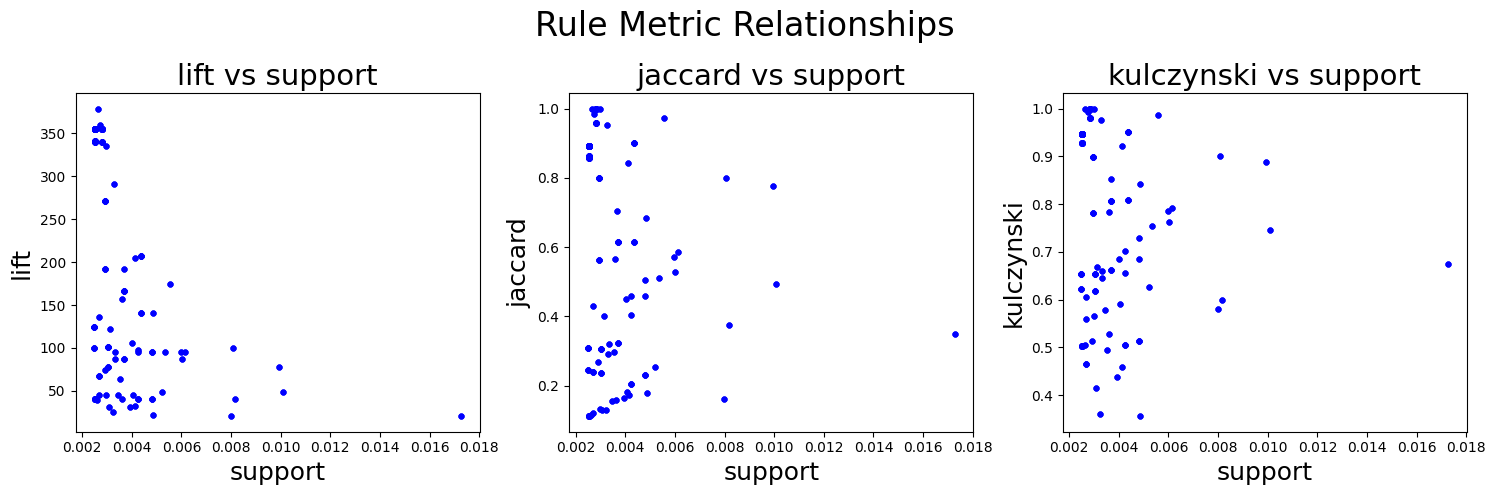

In [42]:
# Construct a 3-panel scatterplot comparing lift, jaccard, and kulczynski measures
# of the generated rule metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Construct a scatter plot for each metric, adjusted transparency, size, and color for readability
for ax, y_metric in zip(axes, ['lift', 'jaccard', 'kulczynski']):
    ax.scatter(rules_df['support'], rules_df[y_metric],
               alpha=1, s=12, color='blue')
    ax.set_xlabel('support', fontsize=18, color='black')
    ax.set_ylabel(y_metric, fontsize=18, color='black')
    ax.set_title(f'{y_metric} vs support', fontsize=21, color='black')

plt.suptitle("Rule Metric Relationships", fontsize=24, color='black')
plt.tight_layout()
plt.show()

Plots the relationships between my chosen rule evaluation metrics against support. Interestingly, the rules with lower supports seem to have the best scores for Jaccard, Kulczynski, and lift respectively. A lot of these "outlier rules" are the ones with the highest support values.

In [43]:
# Peek at the "outlier rules"
rules_df.sort_values(by='support', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({University of Chinese Academy of Sciences}),frozenset({Chinese Academy of Sciences}),0.01728,0.04932,0.01728,1.000000,20.275750,1.0,0.016428,inf,0.967397,0.350365,1.000000,0.675182
1,frozenset({Chinese Academy of Sciences}),frozenset({University of Chinese Academy of Sciences}),0.04932,0.01728,0.01728,0.350365,20.275750,1.0,0.016428,1.512726,1.000000,0.350365,0.338942,0.675182
2,frozenset({University College London}),frozenset({University of London}),0.01008,0.02044,0.01008,1.000000,48.923679,1.0,0.009874,inf,0.989535,0.493151,1.000000,0.746575
3,frozenset({University of London}),frozenset({University College London}),0.02044,0.01008,0.01008,0.493151,48.923679,1.0,0.009874,1.953085,1.000000,0.493151,0.487990,0.746575
4,frozenset({Office of Science}),frozenset({United States Department of Energy}),0.00994,0.01278,0.00994,1.000000,78.247261,1.0,0.009813,inf,0.997131,0.777778,1.000000,0.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,"frozenset({United States Department of Health and Human Services, National C...",frozenset({National Institutes of Health}),0.00248,0.00806,0.00248,1.000000,124.069479,1.0,0.002460,inf,0.994406,0.307692,1.000000,0.653846
320,"frozenset({National Institutes of Health, National Cancer Institute [4210140...",frozenset({United States Department of Health and Human Services}),0.00248,0.01006,0.00248,1.000000,99.403579,1.0,0.002455,inf,0.992401,0.246521,1.000000,0.623260
321,frozenset({United States Department of Health and Human Services}),"frozenset({National Institutes of Health, National Cancer Institute [4210140...",0.01006,0.00248,0.00248,0.246521,99.403579,1.0,0.002455,1.323885,1.000000,0.246521,0.244648,0.623260
322,frozenset({National Institutes of Health}),"frozenset({United States Department of Health and Human Services, National C...",0.00806,0.00248,0.00248,0.307692,124.069479,1.0,0.002460,1.440862,1.000000,0.307692,0.305971,0.653846


When sorted by support, there is a much greater diversity of institution pairings compared to when sorted by Kulczynski. When sorted by Jaccard and Kulczynski, the only rules were ones consisting of French institutes suggesting that they depend on each other more than these pairs. These pairings here constitute the "outliers" on the rule metric relationship plots. This includes both groupings of federal institutions and universities collaborating with their satellite campuses. The lower symmetry here suggests that one institution publishes indepenently or with a different partner more frequently compared to the French institutes.